# 

# HW 1 - Multiple Linear Regression

In [ ]:
# AE 498 HW1 AMANDA YAKLIN 
# YAKLIN2@ILLINOIS.EDU

In [164]:
import numpy as np
import scipy
from scipy import stats
import pandas as pd
import statsmodels as sm
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

# specify your filepath
filepath = 'C:/Users/Amanda/AE498_homework/hw1-mlr/data/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2026_1.csv'

predictors = ['DepDelay','Distance','ActualElapsedTime']
anova_remove = [1,2] # use anova to see how these predictors affect the outcome
out = ['ArrDelay']
numrows = 50000 # subset of data to use

def csv_to_input(filepath,predictors,out,numpy=True):
    # function to convert raw data to useful arrays
    # X: input array - each row is an observation and each column is a predictor. n x (p+1). First column is all 1s.
    # y: observation array - n elements 
    n = len(predictors)
    #print('reading csv...')
    csv = pd.read_csv(filepath, delimiter=',',usecols=predictors,nrows=numrows)
    obs_csv = pd.read_csv(filepath, delimiter=',',usecols=out,nrows=numrows)
    df = pd.DataFrame(csv)
    obs_df = pd.DataFrame(obs_csv)
    # predictors
    x0 = np.ones(len(df[predictors[0]].to_numpy()))
    X = np.vstack([x0, np.array(list(df[predictors[i]] for i in range(n)))]).T
    # observations 
    if numpy:
        y = obs_df['ArrDelay'].to_numpy()
    else:
        y = obs_df['ArrDelay']
        X = pd.DataFrame(X)

    # Keep rows where X has no NaNs AND Y has no NaNs
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[mask, :]
    y = y[mask]
    return X, y

def normalize_data(X):
    """Function to normalize input data to [-1, 1].

    Parameters
    ----------
    X : array_like
        Input data (n x (p + 1) dimensions), where each row is an observation and each column is a predictor. 
        The first column should be all ones.
    Returns
    -------
    X_normalized : array_like
        Input data (n x (p + 1) dimensions) normalized to the range [-1, 1].

    """

    n, n_columns = np.shape(X)

    # normalize each column
    X_normalized = np.ones((n, n_columns))
    for column in range(n_columns):
        x_column = X[:, column]
        x_max = max(x_column)
        x_min = min(x_column)
        if x_max != x_min:
            x_column_normalized = [
                (x - (x_max + x_min) / 2) / ((x_max - x_min) / 2) for x in x_column
            ]
            X_normalized[:, column] = x_column_normalized

    return X_normalized

def mlr(filepath,predictors,out):
    X, y = csv_to_input(filepath,predictors,out,numpy=True)
    # Fit the Ordinary Least Squares model
    model = sm.regression.linear_model.OLS(y, X).fit()
    
    # Return the estimated coefficients
    print("model coefficients",model.params)
    return X, y, model.params

def mlr_line(X, X_bar, beta, i):
    """
    function to get the predicted multiple linear regression 
    for the ith predictor. All X's except the ith X are fixed
    at their mean value. 
    The resulting curve is y_hat = B1*x1_bar + B2*x2_bar + ... + Bi*xi + ... + Bp*xp_bar
    inputs:
        X: Input data (n x (p + 1) dimensions), where each row is an observation and each column is a predictor. 
        The first column should be all ones.
        X_bar: Means of X, taken along axis 1, array-like
        beta: Model coefficients, array-like
        i: index of predictor, int
    """
    y_hat = X_bar @ beta - beta[i]*X_bar[i] + X.T[i]*beta[i]
    #print("yhat",y_hat)
    return y_hat

def scatterplot(filepath,predictors,out,compare=False):
    """
    function to generate scatterplot matrix for BTS data and compare
    to prediction by MLR.
    inputs: 
        filepath: including the file name of the dataset, string
        predictors: strings referring to the columns used for predictors, list-like
    output:
        out: name of the column of observations, string
    """
    X, y, beta = mlr(filepath,predictors,out)
    n = X.shape[1]    
    X_bar = np.mean(X, axis=0)
    
    fig, axes = plt.subplots(
        nrows=n-1,
        ncols=2,
        figsize=(12, 3 * (n-1))
    )
    
    for i, col in enumerate(X.T):
        if i>0:
            j=i-1
            if compare:
                axes[j, 0].plot(col, mlr_line(X,X_bar,beta,i), color='red',lw='3')
            axes[j, 0].scatter(col, y)
            axes[j, 0].set_xlabel(predictors[j])
            axes[j, 0].set_ylabel("Arrival Delay (minutes)")

            axes[j, 1].hist(col, bins=20)
            axes[j, 1].set_xlabel(predictors[j])
            axes[j, 1].set_ylabel("Frequency")

            axes[j, 0].grid(visible=True)
            #axes[j,0].set_ylim(0,100)
                
    plt.tight_layout()
    plt.show()
    
def anova(filepath,predictors,out):
    X, y = csv_to_input(filepath,predictors,out,numpy=True)
    X = normalize_data(X)
    reduced = np.delete(X, anova_remove, axis=1)
    
    model = sm.regression.linear_model.OLS(y,X, missing='raise')
    results = model.fit()
    reduced_model = sm.regression.linear_model.OLS(y,reduced, missing='raise')
    reduced_results = reduced_model.fit()
    f_stat, p_value, df_diff = results.compare_f_test(reduced_results)
    print(f"effect of {predictors[anova_remove[0]]}, {predictors[anova_remove[1]]} on arrDelay")
    print(f"f stat: {f_stat}\np value: {p_value}\ndifference: {df_diff}")

anova(filepath,predictors,out)

"""
Since the number of samples is very large, the F-test is evidently
not very effective at determining the usefulness of the 
predictors. Now we will try hypothesis testing on each predictor.
"""
def coefficient_tests(filepath,predictors,out,index):
    X, y, coefficients = mlr(filepath,predictors,out)
    y_predicted = X @ coefficients
    # no. of observations
    n = X.shape[0]
    # no. of predictors
    p = X.shape[1]
    # diagonal of (xTx)^-1 
    xTx_inv = np.linalg.inv(X.T @ X)
    v = np.diag(xTx_inv)  
                
    # standard error of model
    stderr_betas = np.sqrt(((np.sum((y_predicted - y)**2)) / (n - p)) * v)
    
    t_statistics = coefficients / stderr_betas
    
    # p values
    # since t-distribution is symmetric, multiply by 2
    # since the lowest p-value is very low (O(1e-19)), 
    # use stats.sf (survival function) to prevent floating point error
    p_values = 2 * stats.t.sf(np.abs(t_statistics), n - p) 
    
    return p_values, t_statistics

for i in range(len(predictors)):
    p, t = coefficient_tests(filepath,predictors,out,i+1)
    print(f"p:{p}\nt:{t}")


effect of Distance, ActualElapsedTime on arrDelay
f stat: 1167989.683058384
p value: 0.0
difference: 2.0
model coefficients [-25.75129667   1.00686056  -0.05144426   0.4259828 ]
p:[0. 0. 0. 0.]
t:[-152.77941859 1511.14154925 -164.82002998  166.37615446]
model coefficients [-25.75129667   1.00686056  -0.05144426   0.4259828 ]
p:[0. 0. 0. 0.]
t:[-152.77941859 1511.14154925 -164.82002998  166.37615446]
model coefficients [-25.75129667   1.00686056  -0.05144426   0.4259828 ]
p:[0. 0. 0. 0.]
t:[-152.77941859 1511.14154925 -164.82002998  166.37615446]


In [165]:
#scatterplot(filepath,predictors,out,compare=False)

(45440, 4)
[-25.75129667   1.00686056  -0.05144426   0.4259828 ]
yhat [-10.12217695 -13.14275863  -9.11531639 ...  -7.10159528  45.25515382
 -14.14961919]
yhat [-59.40689497 -59.40689497 -59.40689497 ...  17.0392821   17.0392821
  17.0392821 ]
yhat [123.16593979 106.55261051 100.16286847 ...  26.4678437   18.80015326
  14.96630804]


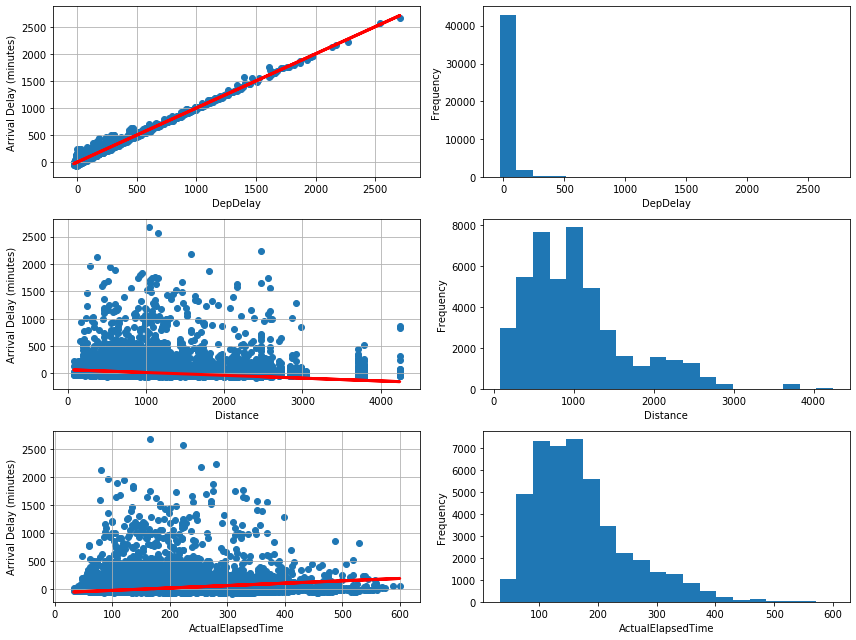

In [159]:
scatterplot(filepath,predictors,out,compare=True) 

'''
Results:
The plots are generated using a random sample of 50k flights during
January of 2026. 

With a large number (50k) datapoints, ANOVA and the t-test for coefficients
yield extremely low p-values (~0) and high t and F statistics. This is
because the standard error has sqrt(n-p) in the denominator. For n=50000 and
p=3, the resulting value of standard error is on the order of 10^-5. 
A very small standard error can make any predictor appear significant.

Consequently, we assess the effect of inputs using the coefficients 
rather than whether the null hypothesis was rejected.

Plot 1 - Since departure delay (minutes) is a direct component of arrival delay, the quantities show a positive, linear relationship. The corresponding
model coefficient is 1.006, which is the greatest of the three.

Plot 2 - The distance (miles) between the origin and arrival 
airports shows slight inverse correlation with flight delay. 
Longer distance flights apparently tend to have less delay, however, there 
are fewer longer flights (> 1000 miles) than shorter flights. The corresponding
model coefficient is -0.051, which is the smallest of the three.

Plot 3 - The actual elapsed time (minutes) of the flight has the second highest
corresponding model coefficient (0.426). This can be attributed to the fact
that delays are incorporated into the actual elapsed time. Since
flight delay is not always the greatest contributor to flight duration, the
correlation is expected to be weaker than that of departure delay.

'''

2e-05